# Adversarial Reprogramming of Neural Networks
### Based on: Elsayed, Goodfellow & Sohl-Dickstein (ICLR 2019) — arXiv:1806.11146

---

## What is Adversarial Reprogramming?

Traditional adversarial attacks try to **fool** a model (make it misclassify).

**Adversarial Reprogramming** is different — it **hijacks** a model to perform a completely new task the attacker chooses, **without changing the model's weights**.

> **Analogy:** Imagine a calculator designed to add numbers. Adversarial reprogramming is like finding a way to press keys in a specific pattern so the calculator secretly computes square roots instead — without physically modifying the calculator.

---

### Key Idea from the Paper
- Take a pre-trained ImageNet classifier (e.g., ResNet, Inception)
- Add a **learned adversarial program** (a background pattern) around the input
- The model now performs a **different task** (e.g., count squares, classify MNIST digits)
- The model weights are **never changed** — only the input is modified

![Concept Diagram](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*7ZKhEzJAhBqX3OTK.png)


## 0. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from sklearn.datasets import load_digits, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
print("All imports successful!")

All imports successful!


---
## 1. Visual Overview: The Big Picture

Let's visualize the core concept before diving into math.

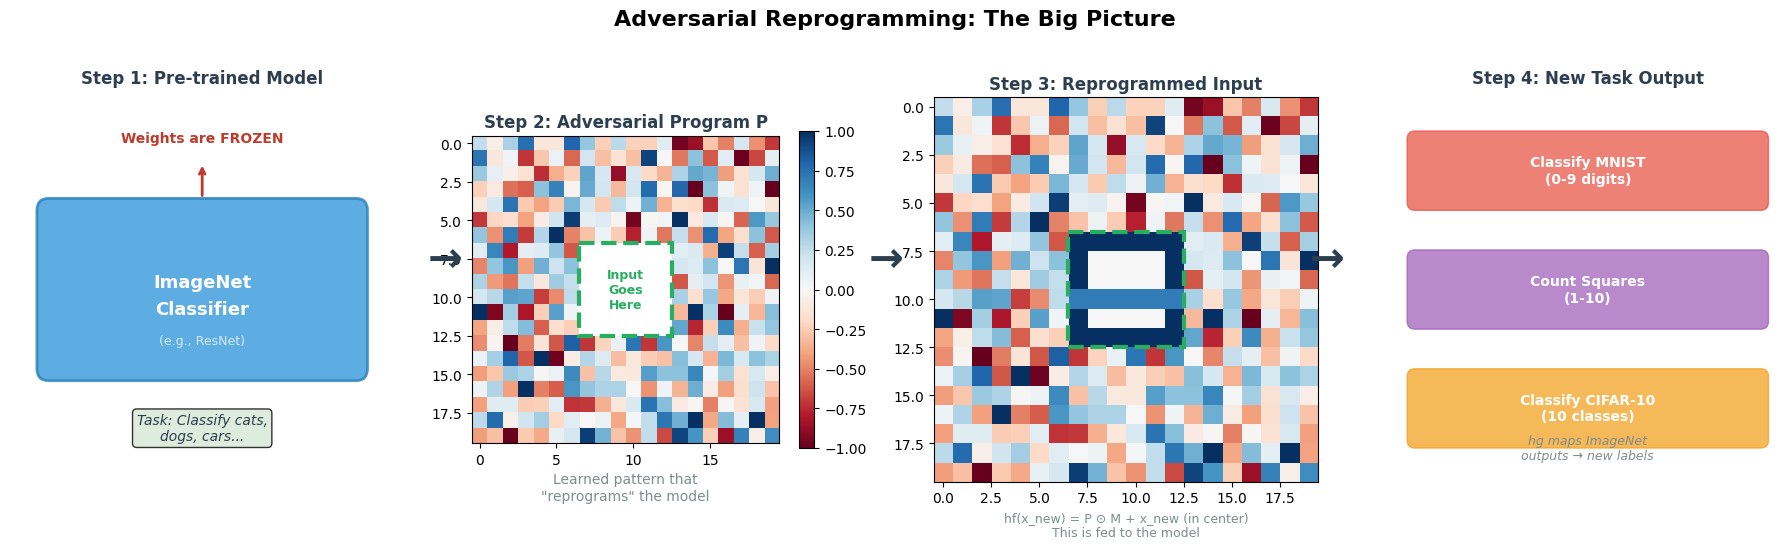

Figure saved!


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Adversarial Reprogramming: The Big Picture', fontsize=16, fontweight='bold', y=1.02)

# --- Panel 1: Original Model ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Step 1: Pre-trained Model', fontsize=12, fontweight='bold', color='#2c3e50')

# Draw model box
rect = mpatches.FancyBboxPatch((1, 3), 8, 4, boxstyle="round,pad=0.3",
                                 facecolor='#3498db', alpha=0.8, edgecolor='#2980b9', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5.2, 'ImageNet', ha='center', va='center', fontsize=13, fontweight='bold', color='white')
ax.text(5, 4.5, 'Classifier', ha='center', va='center', fontsize=13, fontweight='bold', color='white')
ax.text(5, 3.7, '(e.g., ResNet)', ha='center', va='center', fontsize=9, color='#d6eaf8')
ax.text(5, 1.5, 'Task: Classify cats,\ndogs, cars...', ha='center', va='center',
        fontsize=10, style='italic', color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#d5e8d4', alpha=0.8))
ax.text(5, 9, 'Weights are FROZEN', ha='center', va='top', fontsize=10,
        color='#c0392b', fontweight='bold')
ax.annotate('', xy=(5, 8.2), xytext=(5, 7.3),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))

# --- Panel 2: Adversarial Program ---
ax = axes[1]
ax.set_title('Step 2: Adversarial Program P', fontsize=12, fontweight='bold', color='#2c3e50')

# Visualize the adversarial program as a noisy pattern
adversarial_prog = np.random.randn(20, 20) * 0.5
# Create a mask: the center is empty (for the real input)
mask = np.ones((20, 20))
mask[7:13, 7:13] = 0  # center hole
adversarial_prog_masked = adversarial_prog * mask

im = ax.imshow(adversarial_prog_masked, cmap='RdBu', vmin=-1, vmax=1)
# Draw center rectangle to show where input goes
rect2 = plt.Rectangle((6.5, 6.5), 6, 6, linewidth=3, edgecolor='#27ae60',
                         facecolor='white', linestyle='--')
ax.add_patch(rect2)
ax.text(9.5, 9.5, 'Input\nGoes\nHere', ha='center', va='center',
        fontsize=9, color='#27ae60', fontweight='bold')
ax.set_xlabel('Learned pattern that\n"reprograms" the model', fontsize=10, color='#7f8c8d')
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Panel 3: Reprogrammed Input ---
ax = axes[2]
ax.set_title('Step 3: Reprogrammed Input', fontsize=12, fontweight='bold', color='#2c3e50')

# Create a combined image: adversarial background + small input in center
combined = adversarial_prog.copy()
# Place a simple digit-like pattern in the center
digit_pattern = np.zeros((6, 6))
digit_pattern[0, :] = 1; digit_pattern[-1, :] = 1  # horizontal bars
digit_pattern[:, 0] = 1; digit_pattern[:, -1] = 1  # vertical bars
digit_pattern[3, :] = 0.7  # middle bar
combined[7:13, 7:13] = digit_pattern

ax.imshow(combined, cmap='RdBu', vmin=-1, vmax=1)
rect3 = plt.Rectangle((6.5, 6.5), 6, 6, linewidth=3, edgecolor='#27ae60',
                         facecolor='none', linestyle='--')
ax.add_patch(rect3)
ax.set_xlabel('hf(x_new) = P ⊙ M + x_new (in center)\nThis is fed to the model', fontsize=9, color='#7f8c8d')

# --- Panel 4: New Task Output ---
ax = axes[3]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Step 4: New Task Output', fontsize=12, fontweight='bold', color='#2c3e50')

# Output remapping visualization
tasks = ['Classify MNIST\n(0-9 digits)', 'Count Squares\n(1-10)', 'Classify CIFAR-10\n(10 classes)']
colors = ['#e74c3c', '#9b59b6', '#f39c12']
for i, (task, color) in enumerate(zip(tasks, colors)):
    y = 8 - i * 3
    rect = mpatches.FancyBboxPatch((0.5, y - 0.8), 9, 1.6,
                                     boxstyle="round,pad=0.2",
                                     facecolor=color, alpha=0.7,
                                     edgecolor=color)
    ax.add_patch(rect)
    ax.text(5, y, task, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')

ax.text(5, 1.0, 'hg maps ImageNet\noutputs → new labels', ha='center', va='center',
        fontsize=9, style='italic', color='#7f8c8d')

# Add arrows between panels (using figure coordinates)
for i in range(3):
    fig.text(0.25 + i * 0.245, 0.52, '→', fontsize=30, ha='center', va='center',
             color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.savefig('concept_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

---
## 2. Mathematical Formulation

The paper defines adversarial reprogramming precisely. Let's break it down:

### 2.1 The Setup

| Symbol | Meaning |
|--------|---------|
| $f$ | Pre-trained model (e.g., ImageNet classifier) — **weights frozen** |
| $X_{new}$ | Input from the new task (e.g., an MNIST digit) |
| $P$ | **Adversarial program** — a learned perturbation pattern |
| $M$ | Binary mask — defines where the adversarial pattern goes |
| $h_f$ | **Input mapping**: transforms new-task input into model input |
| $h_g$ | **Output mapping**: maps model output labels → new task labels |

### 2.2 The Adversarial Program (Key Equation)

The reprogrammed input is constructed as:

$$\tilde{X} = h_f(X_{new}; P) = \tanh(P \odot M + X_{new} \text{ (embedded in center)})$$

Where:
- $P \odot M$ = adversarial pattern applied **only** to the background (outside the input region)
- $X_{new}$ is **embedded** in the center of the larger image
- $\tanh$ clips values to $[-1, 1]$ to keep valid pixel range

### 2.3 The Optimization Objective

Find the adversarial program $P$ that minimizes:

$$\underset{P}{\min} \sum_{(X_{new}, y_{new}) \in D_{new}} \mathcal{L}\bigg(f\big(h_f(X_{new}; P)\big),\; h_g(y_{new})\bigg)$$

In plain English:
> "Find the background pattern $P$ such that when we feed reprogrammed inputs to the frozen model, it produces outputs that (after remapping) correctly solve our new task."

### 2.4 Output Remapping $h_g$

Since the model has $N$ ImageNet classes but our new task has $K$ classes:
- We assign $N/K$ ImageNet classes to each new-task class
- A new-task prediction is correct if **any** of the assigned ImageNet classes is the top prediction

---
## 3. Visualizing the Key Mechanism: Masking and Embedding

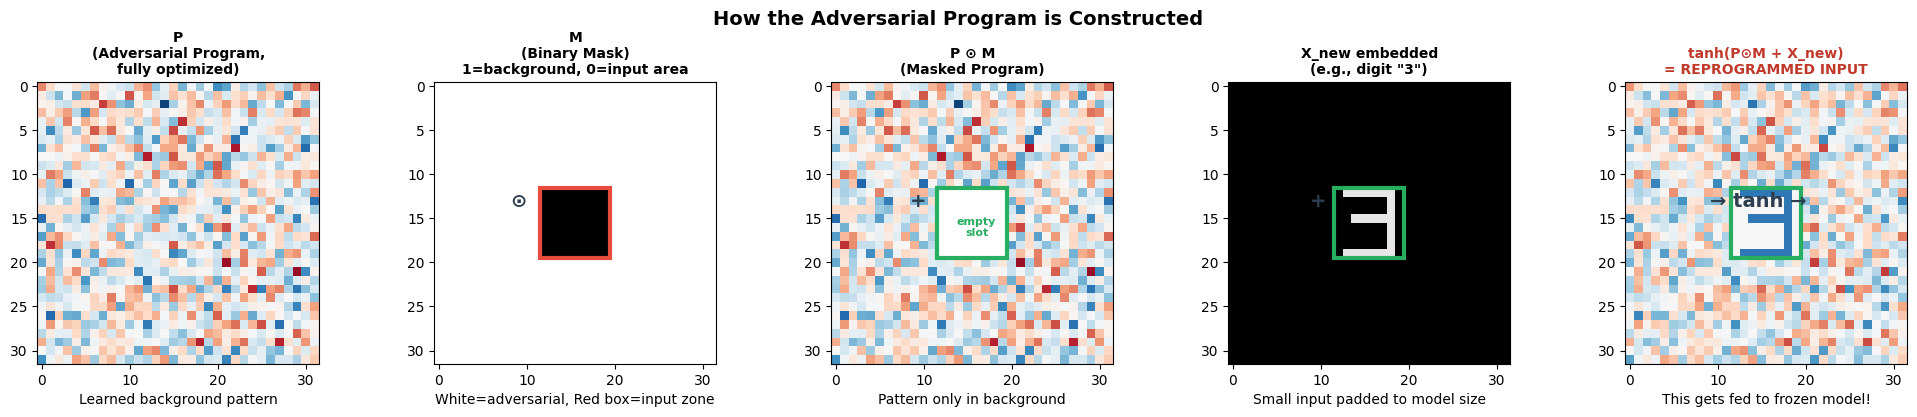

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('How the Adversarial Program is Constructed', fontsize=14, fontweight='bold')

# Simulate: ImageNet model expects 32x32 input, new task is 8x8
IMG_SIZE = 32
INPUT_SIZE = 8
offset = (IMG_SIZE - INPUT_SIZE) // 2  # center the input

# 1. The adversarial program P (raw, before masking)
P = np.random.randn(IMG_SIZE, IMG_SIZE) * 0.3
axes[0].imshow(P, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('P\n(Adversarial Program,\nfully optimized)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Learned background pattern')

# 2. The mask M
M = np.ones((IMG_SIZE, IMG_SIZE))
M[offset:offset+INPUT_SIZE, offset:offset+INPUT_SIZE] = 0  # hole in center
axes[1].imshow(M, cmap='gray', vmin=0, vmax=1)
rect = plt.Rectangle((offset-0.5, offset-0.5), INPUT_SIZE, INPUT_SIZE,
                       linewidth=3, edgecolor='#e74c3c', facecolor='none')
axes[1].add_patch(rect)
axes[1].set_title('M\n(Binary Mask)\n1=background, 0=input area', fontsize=10, fontweight='bold')
axes[1].set_xlabel('White=adversarial, Red box=input zone')

# 3. P ⊙ M (masked adversarial program)
P_masked = P * M
axes[2].imshow(P_masked, cmap='RdBu', vmin=-1, vmax=1)
rect2 = plt.Rectangle((offset-0.5, offset-0.5), INPUT_SIZE, INPUT_SIZE,
                        linewidth=3, edgecolor='#27ae60', facecolor='white')
axes[2].add_patch(rect2)
axes[2].text(IMG_SIZE//2, IMG_SIZE//2, 'empty\nslot', ha='center', va='center',
             fontsize=8, color='#27ae60', fontweight='bold')
axes[2].set_title('P ⊙ M\n(Masked Program)', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Pattern only in background')

# 4. The new task input X_new (e.g., digit '3')
X_new_small = np.zeros((INPUT_SIZE, INPUT_SIZE))
# Draw a crude '3'
X_new_small[0, 1:7] = 0.9   # top
X_new_small[3, 2:7] = 0.9   # middle
X_new_small[7, 1:7] = 0.9   # bottom
X_new_small[1:3, 6] = 0.9   # top right
X_new_small[4:7, 6] = 0.9   # bottom right

X_new_large = np.zeros((IMG_SIZE, IMG_SIZE))
X_new_large[offset:offset+INPUT_SIZE, offset:offset+INPUT_SIZE] = X_new_small
axes[3].imshow(X_new_large, cmap='gray', vmin=0, vmax=1)
rect3 = plt.Rectangle((offset-0.5, offset-0.5), INPUT_SIZE, INPUT_SIZE,
                        linewidth=3, edgecolor='#27ae60', facecolor='none')
axes[3].add_patch(rect3)
axes[3].set_title('X_new embedded\n(e.g., digit "3")', fontsize=10, fontweight='bold')
axes[3].set_xlabel('Small input padded to model size')

# 5. Final reprogrammed input = P_masked + X_new_large
X_reprogrammed = np.tanh(P_masked + X_new_large)
axes[4].imshow(X_reprogrammed, cmap='RdBu', vmin=-1, vmax=1)
rect4 = plt.Rectangle((offset-0.5, offset-0.5), INPUT_SIZE, INPUT_SIZE,
                        linewidth=3, edgecolor='#27ae60', facecolor='none')
axes[4].add_patch(rect4)
axes[4].set_title('tanh(P⊙M + X_new)\n= REPROGRAMMED INPUT', fontsize=10, fontweight='bold',
                   color='#c0392b')
axes[4].set_xlabel('This gets fed to frozen model!')

# Operators between panels
for i, op in enumerate(['⊙', '+', '+', '→ tanh →']):
    x_pos = (i + 1.5) / 5 - 0.02
    fig.text(x_pos + 0.02*(i==3), 0.5, op, fontsize=14, ha='center', va='center',
             color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.savefig('mechanism_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Simple Toy Example: Reprogramming a Digit Classifier

Let's implement adversarial reprogramming from scratch with a simple example:

**Setup:**
- **Original task:** Classify 8x8 digit images (digits 0-4) — our "ImageNet model"
- **New task:** Classify 4x4 digit images (digits 5-9) — the "attacker's task"
- **Goal:** Without changing the model, use an adversarial program to hijack it for the new task

In [4]:
# ============================================================
# STEP 1: Train the "pre-trained" model on the ORIGINAL task
# ============================================================

# Load digits dataset (8x8 images, digits 0-9)
digits = load_digits()
X_all = digits.images  # shape: (1797, 8, 8)
y_all = digits.target

# Original task: classify digits 0-4
mask_orig = y_all < 5
X_orig = X_all[mask_orig].reshape(-1, 64)  # flatten to 64 features
y_orig = y_all[mask_orig]

# Normalize
scaler = StandardScaler()
X_orig_scaled = scaler.fit_transform(X_orig)

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig_scaled, y_orig, test_size=0.2, random_state=42
)

# Train the "pre-trained" model (our frozen model)
pretrained_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=500,
    random_state=42,
    activation='relu'
)
pretrained_model.fit(X_train_orig, y_train_orig)

orig_acc = accuracy_score(y_test_orig, pretrained_model.predict(X_test_orig))
print(f"Pre-trained model accuracy on ORIGINAL task (digits 0-4): {orig_acc:.1%}")
print(f"Model knows about {len(pretrained_model.classes_)} classes: {pretrained_model.classes_}")
print("\nNOW WE FREEZE THE MODEL — no more weight updates!")
print("The attacker wants to classify digits 5-9 using this frozen model.")

Pre-trained model accuracy on ORIGINAL task (digits 0-4): 99.4%
Model knows about 5 classes: [0 1 2 3 4]

NOW WE FREEZE THE MODEL — no more weight updates!
The attacker wants to classify digits 5-9 using this frozen model.


In [5]:
# ============================================================
# STEP 2: Set up the NEW task
# ============================================================

# New task: classify digits 5-9 (the attacker's target task)
mask_new = y_all >= 5
X_new_raw = X_all[mask_new]  # (N, 8, 8) — same size, but different digits
y_new_raw = y_all[mask_new]  # labels: 5, 6, 7, 8, 9

# Remap labels: 5->0, 6->1, 7->2, 8->3, 9->4 (new task has 5 classes)
y_new_remapped = y_new_raw - 5  # now 0-4
NEW_CLASSES = 5
ORIG_CLASSES = 5  # model outputs 5 classes (digits 0-4)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new_raw, y_new_remapped, test_size=0.2, random_state=42
)

print(f"New task training samples: {len(X_train_new)}")
print(f"New task test samples: {len(X_test_new)}")
print(f"New task labels (remapped): {np.unique(y_new_remapped)} (representing digits 5-9)")

# Output mapping h_g: map model output class i -> new task class i (1-to-1 since same # of classes)
# In the paper with ImageNet (1000 classes) -> 10 new classes, 100 ImageNet classes map to each new class
# Here we have 5->5 so it's a direct mapping
def h_g(model_output_class):
    """Map model's output class to new task class."""
    return model_output_class  # 1-to-1 mapping in this simple case

print("\nOutput mapping h_g: model class i → new task class i (direct, 1-to-1)")

New task training samples: 716
New task test samples: 180
New task labels (remapped): [0 1 2 3 4] (representing digits 5-9)

Output mapping h_g: model class i → new task class i (direct, 1-to-1)


In [6]:
# ============================================================
# STEP 3: Implement the Adversarial Program
# ============================================================

class AdversarialProgram:
    """
    Implements the adversarial program from the paper.
    
    The adversarial program P is a learned perturbation that, when
    added to inputs, causes the frozen model to perform a new task.
    """
    
    def __init__(self, input_size=64, learning_rate=0.01):
        self.input_size = input_size
        self.lr = learning_rate
        # Initialize the adversarial program (the learned perturbation)
        # In the paper: W is the trainable adversarial program
        self.W = np.random.randn(input_size) * 0.01  # small random init
        self.loss_history = []
        self.acc_history = []
    
    def h_f(self, X_new):
        """
        Input mapping: transform new-task input by adding adversarial program.
        
        In the paper: h_f(X_new; P) = tanh(P ⊙ M + X_new embedded in center)
        Here (simplified): h_f(X_new) = X_new + W  (additive adversarial program)
        Then scale to match the pre-trained model's expected input.
        """
        # Add the adversarial perturbation to every input
        X_reprogrammed = X_new + self.W[np.newaxis, :]
        return X_reprogrammed
    
    def compute_accuracy(self, X_new, y_new, model, scaler):
        """Compute accuracy on new task using the reprogrammed model."""
        X_rep = self.h_f(X_new.reshape(-1, 64))
        X_rep_scaled = scaler.transform(X_rep)
        preds = model.predict(X_rep_scaled)
        new_task_preds = np.array([h_g(p) for p in preds])
        return accuracy_score(y_new, new_task_preds)
    
    def train(self, X_train, y_train, model, scaler, n_epochs=50, batch_size=32):
        """
        Train the adversarial program P using gradient-based optimization.
        
        We use numerical gradients (finite differences) since we're treating
        the model as a black box for simplicity.
        In the paper: they use backpropagation through the frozen model.
        """
        n_samples = len(X_train)
        X_flat = X_train.reshape(n_samples, -1)
        
        print("Training adversarial program...")
        print("(Computing gradients to find the optimal perturbation P)")
        print("-" * 50)
        
        for epoch in range(n_epochs):
            # Mini-batch
            idx = np.random.choice(n_samples, batch_size, replace=False)
            X_batch = X_flat[idx]
            y_batch = y_train[idx]
            
            # --- Compute gradient of W using finite differences ---
            # For each dimension, estimate dLoss/dW_i
            eps = 0.01
            grad = np.zeros_like(self.W)
            
            # Current loss
            X_rep = X_batch + self.W[np.newaxis, :]
            X_rep_scaled = scaler.transform(X_rep)
            probs = model.predict_proba(X_rep_scaled)  # shape: (batch, 5)
            
            # Cross-entropy loss: -sum(log(p[y]))
            current_loss = -np.mean(np.log(probs[np.arange(batch_size), y_batch] + 1e-10))
            
            # Approximate gradient for subset of dimensions (for speed)
            sample_dims = np.random.choice(self.input_size, min(20, self.input_size), replace=False)
            for i in sample_dims:
                W_plus = self.W.copy()
                W_plus[i] += eps
                X_rep_plus = X_batch + W_plus[np.newaxis, :]
                X_rep_plus_scaled = scaler.transform(X_rep_plus)
                probs_plus = model.predict_proba(X_rep_plus_scaled)
                loss_plus = -np.mean(np.log(probs_plus[np.arange(batch_size), y_batch] + 1e-10))
                grad[i] = (loss_plus - current_loss) / eps
            
            # Gradient descent update
            self.W -= self.lr * grad
            
            # Log progress
            self.loss_history.append(current_loss)
            if epoch % 10 == 0:
                acc = self.compute_accuracy(X_train[:100], y_train[:100], model, scaler)
                self.acc_history.append((epoch, acc))
                print(f"Epoch {epoch:3d} | Loss: {current_loss:.4f} | Train Acc: {acc:.1%}")
        
        print("-" * 50)
        print("Adversarial program training complete!")

# Create and train the adversarial program
adv_program = AdversarialProgram(input_size=64, learning_rate=0.05)

# Baseline: accuracy WITHOUT adversarial program
baseline_acc = adv_program.compute_accuracy(X_test_new, y_test_new, pretrained_model, scaler)
print(f"Baseline accuracy on NEW task WITHOUT adversarial program: {baseline_acc:.1%}")
print(f"(Random guess would be: {1/NEW_CLASSES:.1%})\n")

Baseline accuracy on NEW task WITHOUT adversarial program: 12.8%
(Random guess would be: 20.0%)



In [7]:
# Train the adversarial program!
adv_program.train(X_train_new, y_train_new, pretrained_model, scaler, 
                  n_epochs=80, batch_size=32)

# Final accuracy WITH adversarial program
final_acc = adv_program.compute_accuracy(X_test_new, y_test_new, pretrained_model, scaler)
print(f"\nFinal accuracy on NEW task WITH adversarial program: {final_acc:.1%}")
print(f"Improvement over baseline: +{(final_acc - baseline_acc):.1%}")

Training adversarial program...
(Computing gradients to find the optimal perturbation P)
--------------------------------------------------
Epoch   0 | Loss: 5.2833 | Train Acc: 16.0%
Epoch  10 | Loss: 4.3318 | Train Acc: 13.0%
Epoch  20 | Loss: 4.3742 | Train Acc: 15.0%
Epoch  30 | Loss: 3.9367 | Train Acc: 14.0%
Epoch  40 | Loss: 3.8550 | Train Acc: 15.0%
Epoch  50 | Loss: 3.4109 | Train Acc: 15.0%


Epoch  60 | Loss: 3.4361 | Train Acc: 11.0%


Epoch  70 | Loss: 3.8086 | Train Acc: 15.0%
--------------------------------------------------
Adversarial program training complete!

Final accuracy on NEW task WITH adversarial program: 17.2%
Improvement over baseline: +4.4%


---
## 5. Visualizing Training Progress

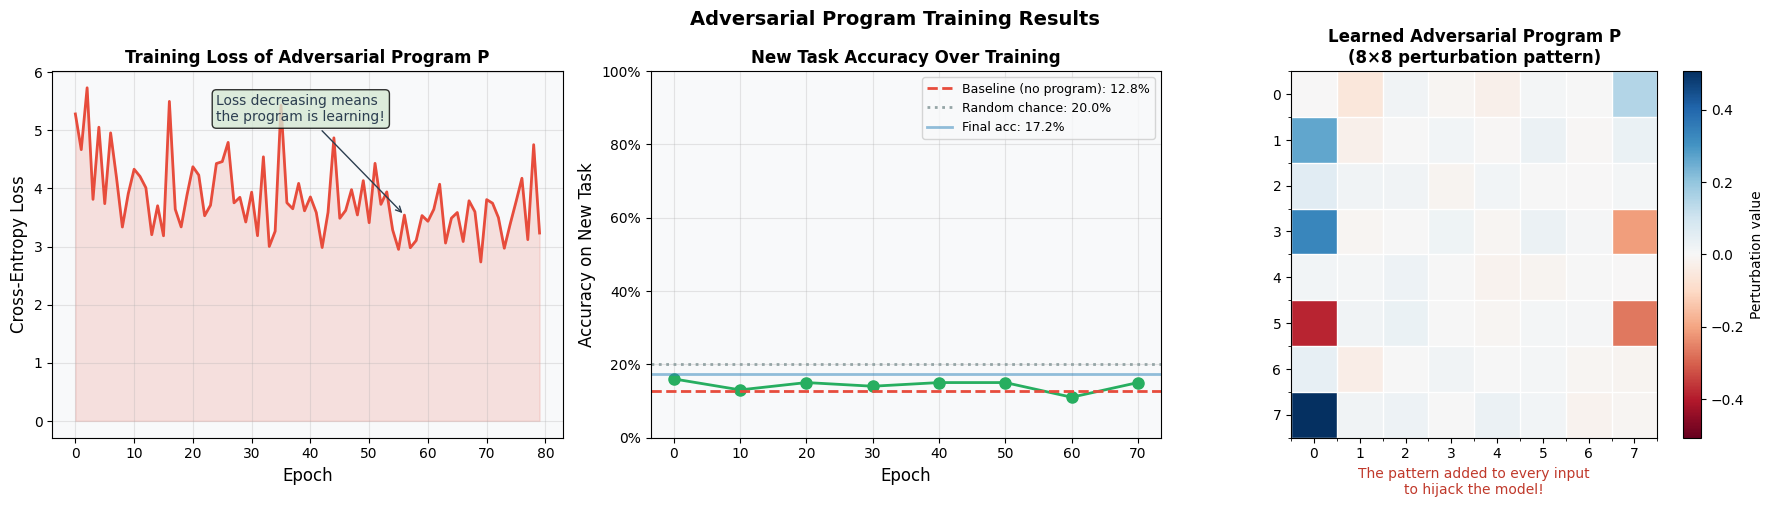

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Adversarial Program Training Results', fontsize=14, fontweight='bold')

# --- Plot 1: Loss curve ---
ax = axes[0]
ax.plot(adv_program.loss_history, color='#e74c3c', linewidth=2)
ax.fill_between(range(len(adv_program.loss_history)), adv_program.loss_history,
                alpha=0.15, color='#e74c3c')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss of Adversarial Program P', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.annotate('Loss decreasing means\nthe program is learning!', 
            xy=(len(adv_program.loss_history)*0.7, adv_program.loss_history[int(len(adv_program.loss_history)*0.7)]),
            xytext=(len(adv_program.loss_history)*0.3, max(adv_program.loss_history)*0.9),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'),
            fontsize=10, color='#2c3e50',
            bbox=dict(boxstyle='round', facecolor='#d5e8d4', alpha=0.8))

# --- Plot 2: Accuracy curve ---
ax = axes[1]
if adv_program.acc_history:
    epochs_acc, accs = zip(*adv_program.acc_history)
    ax.plot(epochs_acc, accs, 'o-', color='#27ae60', linewidth=2, markersize=8)
    ax.axhline(y=baseline_acc, color='#e74c3c', linestyle='--', linewidth=2, label=f'Baseline (no program): {baseline_acc:.1%}')
    ax.axhline(y=1/NEW_CLASSES, color='#95a5a6', linestyle=':', linewidth=2, label=f'Random chance: {1/NEW_CLASSES:.1%}')
    ax.axhline(y=final_acc, color='#2980b9', linestyle='-', linewidth=2, alpha=0.5, label=f'Final acc: {final_acc:.1%}')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy on New Task', fontsize=12)
    ax.set_title('New Task Accuracy Over Training', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# --- Plot 3: Visualize the learned adversarial program W ---
ax = axes[2]
W_img = adv_program.W.reshape(8, 8)
im = ax.imshow(W_img, cmap='RdBu', vmin=-np.abs(W_img).max(), vmax=np.abs(W_img).max())
plt.colorbar(im, ax=ax, label='Perturbation value')
ax.set_title('Learned Adversarial Program P\n(8×8 perturbation pattern)', fontsize=12, fontweight='bold')
ax.set_xlabel('The pattern added to every input\nto hijack the model!', fontsize=10, color='#c0392b')

# Add grid
ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Visualizing the Reprogramming in Action

Let's see what the reprogrammed inputs look like compared to originals.

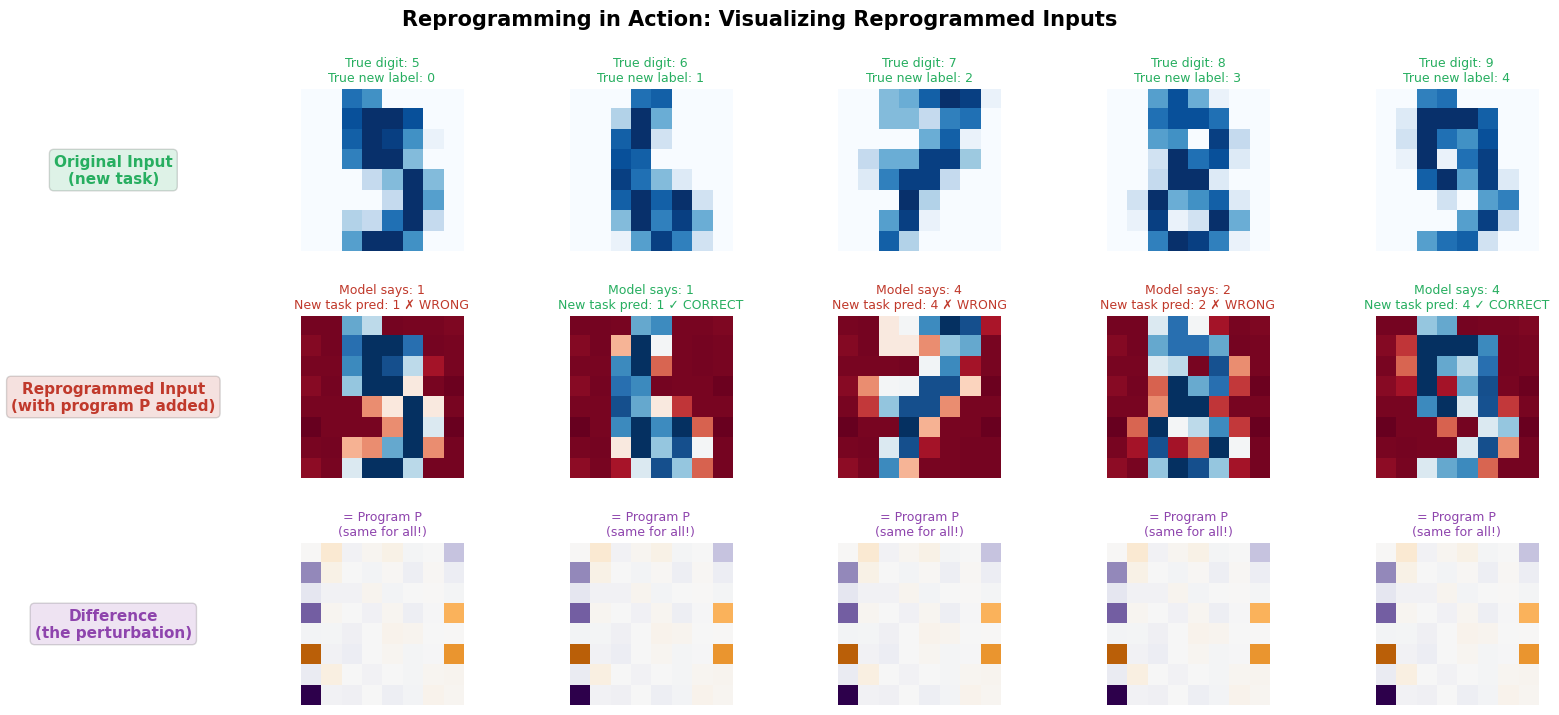

Key insight: The SAME program P is added to ALL inputs — it doesn't change per sample!


In [9]:
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Reprogramming in Action: Visualizing Reprogrammed Inputs', 
             fontsize=15, fontweight='bold')

# Select a few test samples (digits 5-9)
n_show = 5
digit_labels = [5, 6, 7, 8, 9]

# Find one example of each digit
examples = []
for digit in digit_labels:
    # Find samples with this digit
    mask = y_new_raw == digit
    idx = np.where(mask)[0]
    if len(idx) > 0:
        examples.append((X_new_raw[idx[0]], digit))

gs = GridSpec(3, n_show + 1, figure=fig, hspace=0.4, wspace=0.3)

# Row labels
row_labels = ['Original Input\n(new task)', 'Reprogrammed Input\n(with program P added)', 
              'Difference\n(the perturbation)']
row_colors = ['#27ae60', '#c0392b', '#8e44ad']

for row, (label, color) in enumerate(zip(row_labels, row_colors)):
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.axis('off')
    ax_label.text(0.5, 0.5, label, ha='center', va='center', fontsize=11,
                  fontweight='bold', color=color, rotation=0,
                  transform=ax_label.transAxes,
                  bbox=dict(boxstyle='round', facecolor=color, alpha=0.15))

W_img = adv_program.W.reshape(8, 8)

for col, (X_sample, digit) in enumerate(examples):
    X_flat = X_sample.reshape(1, 64)
    X_reprogrammed = adv_program.h_f(X_flat).reshape(8, 8)
    
    # Make predictions
    X_orig_scaled = scaler.transform(X_flat)
    X_rep_scaled = scaler.transform(adv_program.h_f(X_flat))
    
    pred_orig = pretrained_model.predict(X_orig_scaled)[0]  # what model says without program
    pred_rep = pretrained_model.predict(X_rep_scaled)[0]    # what model says with program
    new_task_pred = h_g(pred_rep)  # map to new task label
    true_new_label = digit - 5  # true new task label
    
    correct = new_task_pred == true_new_label
    
    # Row 1: Original input
    ax1 = fig.add_subplot(gs[0, col + 1])
    ax1.imshow(X_sample, cmap='Blues', vmin=0, vmax=16)
    ax1.set_title(f'True digit: {digit}\nTrue new label: {true_new_label}', 
                  fontsize=9, color='#27ae60')
    ax1.axis('off')
    
    # Row 2: Reprogrammed input
    ax2 = fig.add_subplot(gs[1, col + 1])
    ax2.imshow(X_reprogrammed, cmap='RdBu')
    status = '✓ CORRECT' if correct else '✗ WRONG'
    status_color = '#27ae60' if correct else '#c0392b'
    ax2.set_title(f'Model says: {pred_rep}\nNew task pred: {new_task_pred} {status}',
                  fontsize=9, color=status_color)
    ax2.axis('off')
    
    # Row 3: Difference (the perturbation)
    ax3 = fig.add_subplot(gs[2, col + 1])
    diff = X_reprogrammed - X_sample
    max_val = np.abs(diff).max() + 1e-8
    ax3.imshow(diff, cmap='PuOr', vmin=-max_val, vmax=max_val)
    ax3.set_title('= Program P\n(same for all!)', fontsize=9, color='#8e44ad')
    ax3.axis('off')

plt.savefig('reprogramming_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key insight: The SAME program P is added to ALL inputs — it doesn't change per sample!")

---
## 7. The Paper's Real Experiments: ImageNet Reprogramming

The paper tested reprogramming on **6 ImageNet classifiers** with 3 tasks:

| Model | Counting Squares | MNIST | CIFAR-10 |
|-------|-----------------|-------|----------|
| Inception V3 | **97.5%** | **97.3%** | **74.4%** |
| Inception V4 | 97.8% | 97.4% | 73.2% |
| ResNet V2 50 | 91.8% | 92.0% | 62.3% |
| ResNet V2 101 | 93.2% | 93.3% | 65.9% |
| ResNet V2 152 | 95.0% | 95.1% | 67.5% |
| VGG16 | 70.2% | 70.5% | 44.5% |

Let's visualize these results!

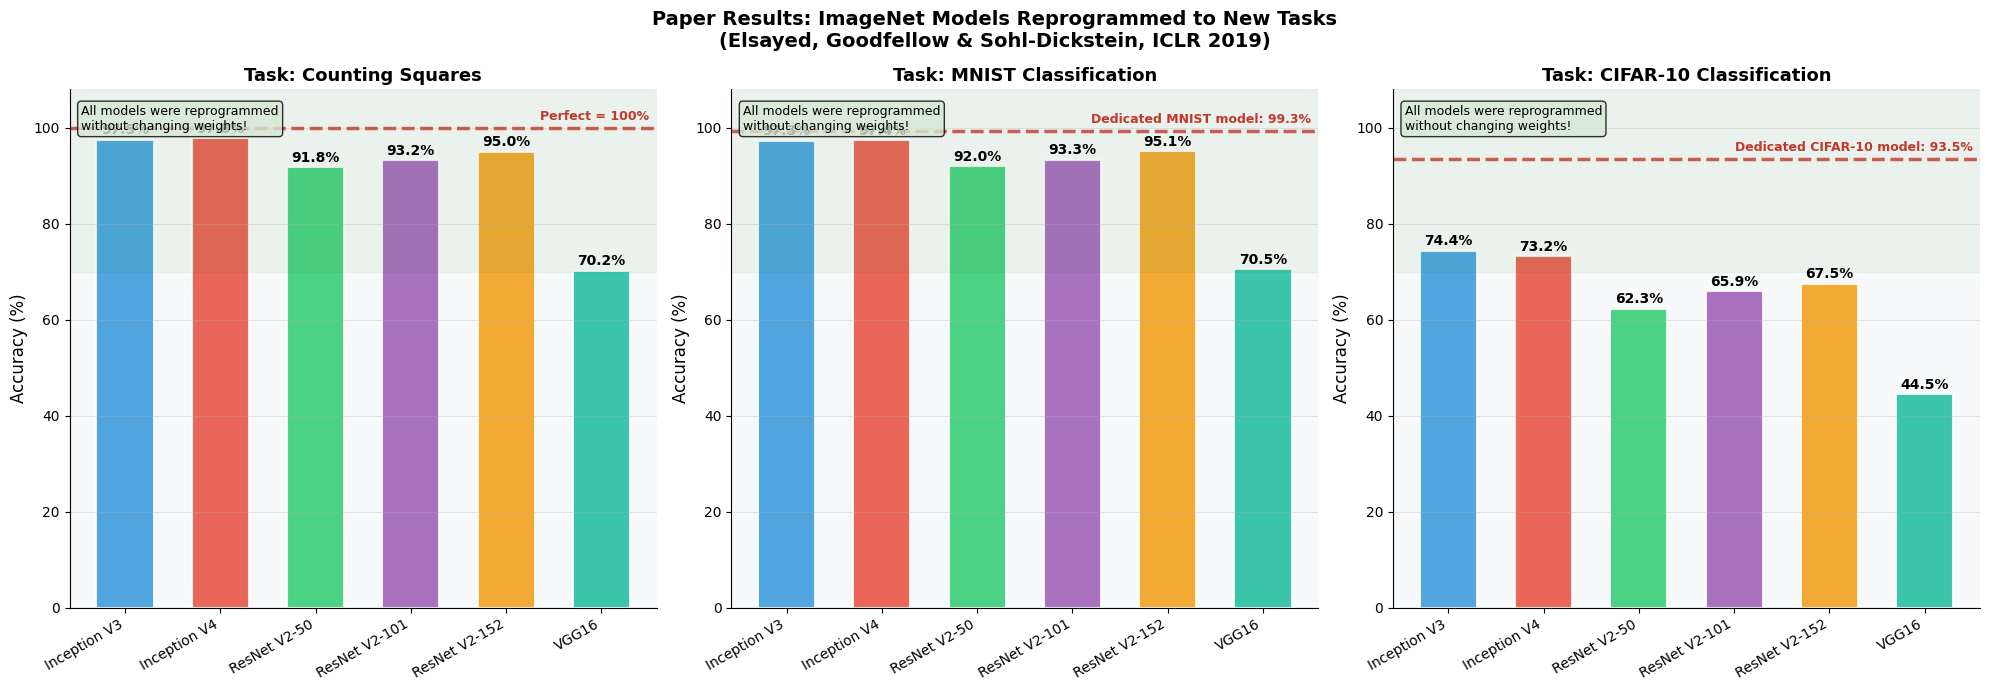

In [10]:
# Paper results from Table 1
models = ['Inception V3', 'Inception V4', 'ResNet V2-50', 'ResNet V2-101', 'ResNet V2-152', 'VGG16']
counting_acc = [97.5, 97.8, 91.8, 93.2, 95.0, 70.2]
mnist_acc = [97.3, 97.4, 92.0, 93.3, 95.1, 70.5]
cifar_acc = [74.4, 73.2, 62.3, 65.9, 67.5, 44.5]

# Baseline comparison (from paper)
mnist_baseline = 99.3  # standard MNIST classifier
cifar_baseline = 93.5  # standard CIFAR-10 classifier

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Paper Results: ImageNet Models Reprogrammed to New Tasks\n(Elsayed, Goodfellow & Sohl-Dickstein, ICLR 2019)',
             fontsize=14, fontweight='bold')

x = np.arange(len(models))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for ax, (task, accs, baseline_label, baseline_val) in zip(
    axes,
    [
        ('Counting Squares', counting_acc, 'Perfect = 100%', 100),
        ('MNIST Classification', mnist_acc, 'Dedicated MNIST model: 99.3%', mnist_baseline),
        ('CIFAR-10 Classification', cifar_acc, 'Dedicated CIFAR-10 model: 93.5%', cifar_baseline),
    ]
):
    bars = ax.bar(x, accs, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5,
                  width=0.6)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Baseline line
    ax.axhline(y=baseline_val, color='#c0392b', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.text(len(models) - 0.5, baseline_val + 1, baseline_label,
            ha='right', va='bottom', fontsize=9, color='#c0392b', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Task: {task}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 108)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Shade the "good" zone
    ax.axhspan(70, 108, alpha=0.05, color='green')
    ax.text(0.02, 0.97, 'All models were reprogrammed\nwithout changing weights!',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#d5e8d4', alpha=0.8))

plt.tight_layout()
plt.savefig('paper_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. How the Input Embedding Works (Paper's Approach)

In the paper, ImageNet models expect **299×299 or 224×224 inputs**, while:
- MNIST digits are **28×28**
- CIFAR-10 images are **32×32**

The solution: **embed the small input in the center** of the larger adversarial program.

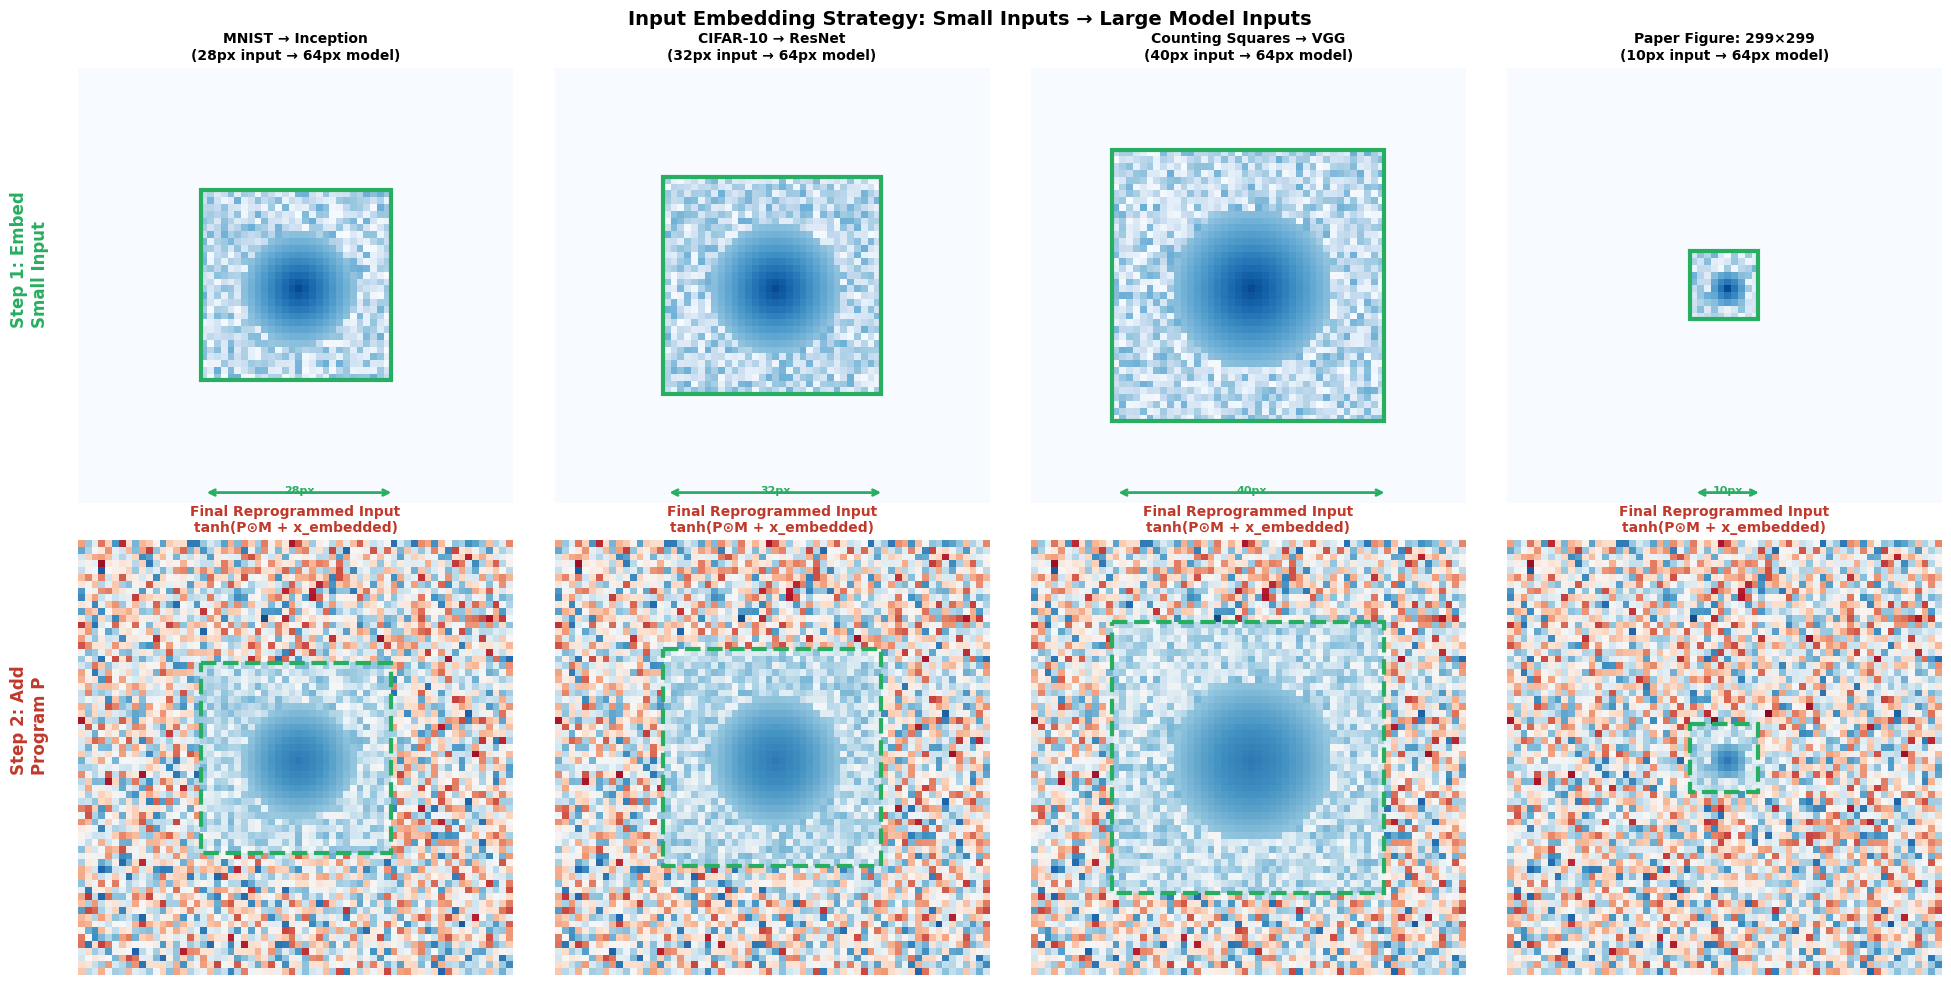

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Input Embedding Strategy: Small Inputs → Large Model Inputs',
             fontsize=14, fontweight='bold')

# Simulate different scale scenarios from the paper
scenarios = [
    {'name': 'MNIST → Inception', 'orig_size': 28, 'model_size': 64, 'task': 'Digit Recognition'},
    {'name': 'CIFAR-10 → ResNet', 'orig_size': 32, 'model_size': 64, 'task': 'Object Recognition'},
    {'name': 'Counting Squares → VGG', 'orig_size': 40, 'model_size': 64, 'task': 'Square Counting'},
    {'name': 'Paper Figure: 299×299', 'orig_size': 10, 'model_size': 64, 'task': 'New Task'},
]

np.random.seed(123)
adv_program_large = np.random.randn(64, 64) * 0.4  # simulated trained program

for col, scenario in enumerate(scenarios):
    orig_size = scenario['orig_size']
    model_size = scenario['model_size']
    offset = (model_size - orig_size) // 2
    
    # Create mask
    mask = np.ones((model_size, model_size))
    mask[offset:offset+orig_size, offset:offset+orig_size] = 0
    
    # Create a simple input image
    X_small = np.random.rand(orig_size, orig_size) * 0.5
    # Add some structure to make it look like an image
    center = orig_size // 2
    for i in range(orig_size):
        for j in range(orig_size):
            dist = np.sqrt((i-center)**2 + (j-center)**2)
            if dist < orig_size * 0.3:
                X_small[i,j] = 0.9 - 0.5 * (dist / (orig_size * 0.3))
    
    # Embed in large image
    X_large = np.zeros((model_size, model_size))
    X_large[offset:offset+orig_size, offset:offset+orig_size] = X_small
    
    # Final reprogrammed input
    adv_masked = adv_program_large * mask
    X_reprogrammed = np.tanh(adv_masked + X_large)
    
    # Row 1: Show the embedding process
    ax1 = axes[0, col]
    ax1.imshow(X_large, cmap='Blues', vmin=0, vmax=1)
    
    # Draw the boundary
    rect = plt.Rectangle((offset-0.5, offset-0.5), orig_size, orig_size,
                          linewidth=3, edgecolor='#27ae60', facecolor='none', linestyle='-')
    ax1.add_patch(rect)
    
    # Labels for scale
    ax1.annotate('', xy=(offset + orig_size, model_size - 2), xytext=(offset, model_size - 2),
                arrowprops=dict(arrowstyle='<->', color='#27ae60', lw=2))
    ax1.text(offset + orig_size/2, model_size - 3, f'{orig_size}px', ha='center', va='top',
             fontsize=8, color='#27ae60', fontweight='bold')
    ax1.set_title(f'{scenario["name"]}\n({orig_size}px input → {model_size}px model)',
                  fontsize=10, fontweight='bold')
    ax1.set_xlabel(f'Task: {scenario["task"]}')
    ax1.axis('off')
    
    # Row 2: Show final reprogrammed input
    ax2 = axes[1, col]
    ax2.imshow(X_reprogrammed, cmap='RdBu', vmin=-1, vmax=1)
    rect2 = plt.Rectangle((offset-0.5, offset-0.5), orig_size, orig_size,
                           linewidth=3, edgecolor='#27ae60', facecolor='none', linestyle='--')
    ax2.add_patch(rect2)
    ax2.set_title(f'Final Reprogrammed Input\ntanh(P⊙M + x_embedded)', 
                  fontsize=10, fontweight='bold', color='#c0392b')
    ax2.set_xlabel('Fed to frozen model as-is')
    ax2.axis('off')

# Add row labels on the side
fig.text(0.02, 0.73, 'Step 1: Embed\nSmall Input', fontsize=12, va='center',
         fontweight='bold', color='#27ae60', rotation=90)
fig.text(0.02, 0.27, 'Step 2: Add\nProgram P', fontsize=12, va='center',
         fontweight='bold', color='#c0392b', rotation=90)

plt.tight_layout(rect=[0.04, 0, 1, 1])
plt.savefig('embedding_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Output Mapping h_g: Remapping Labels

The paper's ImageNet models have **1000 output classes**. New tasks have far fewer.
The output mapping $h_g$ assigns multiple ImageNet classes to each new-task class.

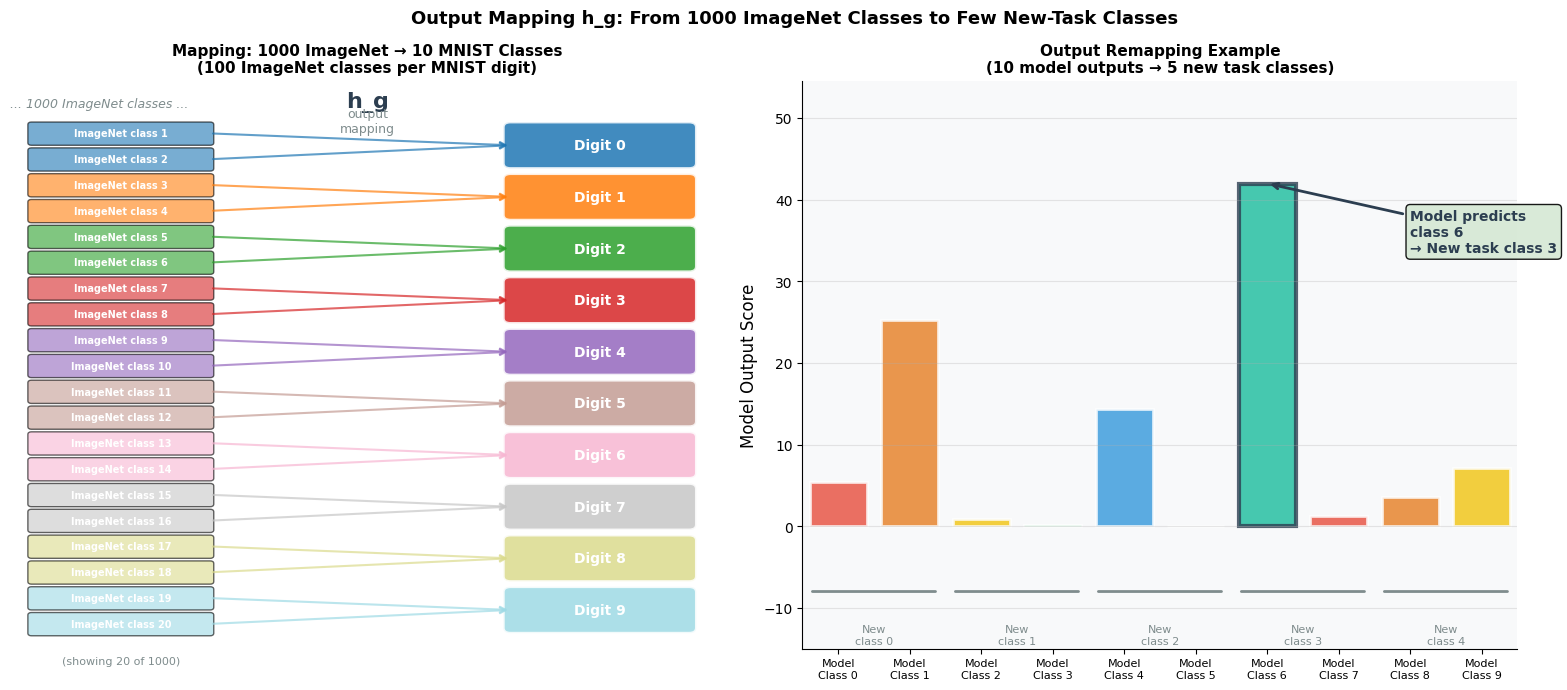

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Output Mapping h_g: From 1000 ImageNet Classes to Few New-Task Classes',
             fontsize=13, fontweight='bold')

# --- Left: Visual mapping diagram ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title('Mapping: 1000 ImageNet → 10 MNIST Classes\n(100 ImageNet classes per MNIST digit)',
             fontsize=11, fontweight='bold')

# Draw ImageNet output (left side)
imagenet_colors = plt.cm.tab20(np.linspace(0, 1, 10))
n_imagenet_show = 20  # show 20 of 1000
for i in range(n_imagenet_show):
    y = 10 - i * 0.5
    color_idx = i // 2  # groups of 2 → same color
    rect = mpatches.FancyBboxPatch((0.3, y - 0.2), 2.5, 0.35,
                                     boxstyle="round,pad=0.05",
                                     facecolor=imagenet_colors[color_idx], alpha=0.6)
    ax.add_patch(rect)
    ax.text(1.55, y - 0.02, f'ImageNet class {i+1}', ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

ax.text(0, 10.5, '... 1000 ImageNet classes ...', fontsize=9, color='#7f8c8d', style='italic')
ax.text(1.55, -0.3, '(showing 20 of 1000)', ha='center', fontsize=8, color='#7f8c8d')

# Draw arrows and new task classes (right side)
new_classes = ['Digit 0', 'Digit 1', 'Digit 2', 'Digit 3', 'Digit 4',
               'Digit 5', 'Digit 6', 'Digit 7', 'Digit 8', 'Digit 9']

for j in range(10):
    y_new = 9.75 - j * 1.0
    rect = mpatches.FancyBboxPatch((7, y_new - 0.35), 2.5, 0.7,
                                     boxstyle="round,pad=0.1",
                                     facecolor=imagenet_colors[j], alpha=0.85,
                                     edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(8.25, y_new, new_classes[j], ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    
    # Draw converging arrows
    for i in range(2):
        y_start = 10 - (j * 2 + i) * 0.5 - 0.02
        ax.annotate('', xy=(7, y_new), xytext=(2.8, y_start),
                   arrowprops=dict(arrowstyle='->', color=imagenet_colors[j],
                                  lw=1.5, alpha=0.7))

ax.text(5, 10.5, 'h_g', ha='center', fontsize=16, fontweight='bold', color='#2c3e50')
ax.text(5, 10.0, 'output\nmapping', ha='center', fontsize=9, color='#7f8c8d')

# --- Right: Bar chart showing assignment ---
ax2 = axes[1]

# Show a simplified example with 10 model outputs → 5 new classes
np.random.seed(42)
model_outputs = np.random.dirichlet(np.ones(10) * 0.5) * 100  # simulated probabilities × 100

# Group colors: 2 model classes per new task class
new_task_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db',
                   '#9b59b6', '#1abc9c', '#e74c3c', '#e67e22', '#f1c40f']
new_task_labels = [f'New class {i//2}' for i in range(10)]

bars = ax2.bar(range(10), model_outputs, color=new_task_colors[:10], alpha=0.8,
               edgecolor='white', linewidth=2)

# Highlight the winning class
winner = np.argmax(model_outputs)
bars[winner].set_edgecolor('#2c3e50')
bars[winner].set_linewidth(3)
ax2.annotate(f'Model predicts\nclass {winner}\n→ New task class {winner//2}',
            xy=(winner, model_outputs[winner]),
            xytext=(winner + 2 if winner < 7 else winner - 3, model_outputs[winner] * 0.8),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2),
            fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round', facecolor='#d5e8d4', alpha=0.9))

# Add group brackets
for g in range(5):
    x_start = g * 2 - 0.4
    x_end = g * 2 + 1.4
    y_bracket = -8
    ax2.annotate('', xy=(x_start, y_bracket), xytext=(x_end, y_bracket),
                arrowprops=dict(arrowstyle='-', color='#7f8c8d', lw=2))
    ax2.text(g * 2 + 0.5, y_bracket - 4, f'New\nclass {g}', ha='center', va='top',
             fontsize=8, color='#7f8c8d')

ax2.set_xlim(-0.5, 9.5)
ax2.set_ylim(-15, max(model_outputs) * 1.3)
ax2.set_xticks(range(10))
ax2.set_xticklabels([f'Model\nClass {i}' for i in range(10)], fontsize=8)
ax2.set_ylabel('Model Output Score', fontsize=12)
ax2.set_title('Output Remapping Example\n(10 model outputs → 5 new task classes)',
              fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Security Implications

Why does this matter from a security and AI safety perspective?

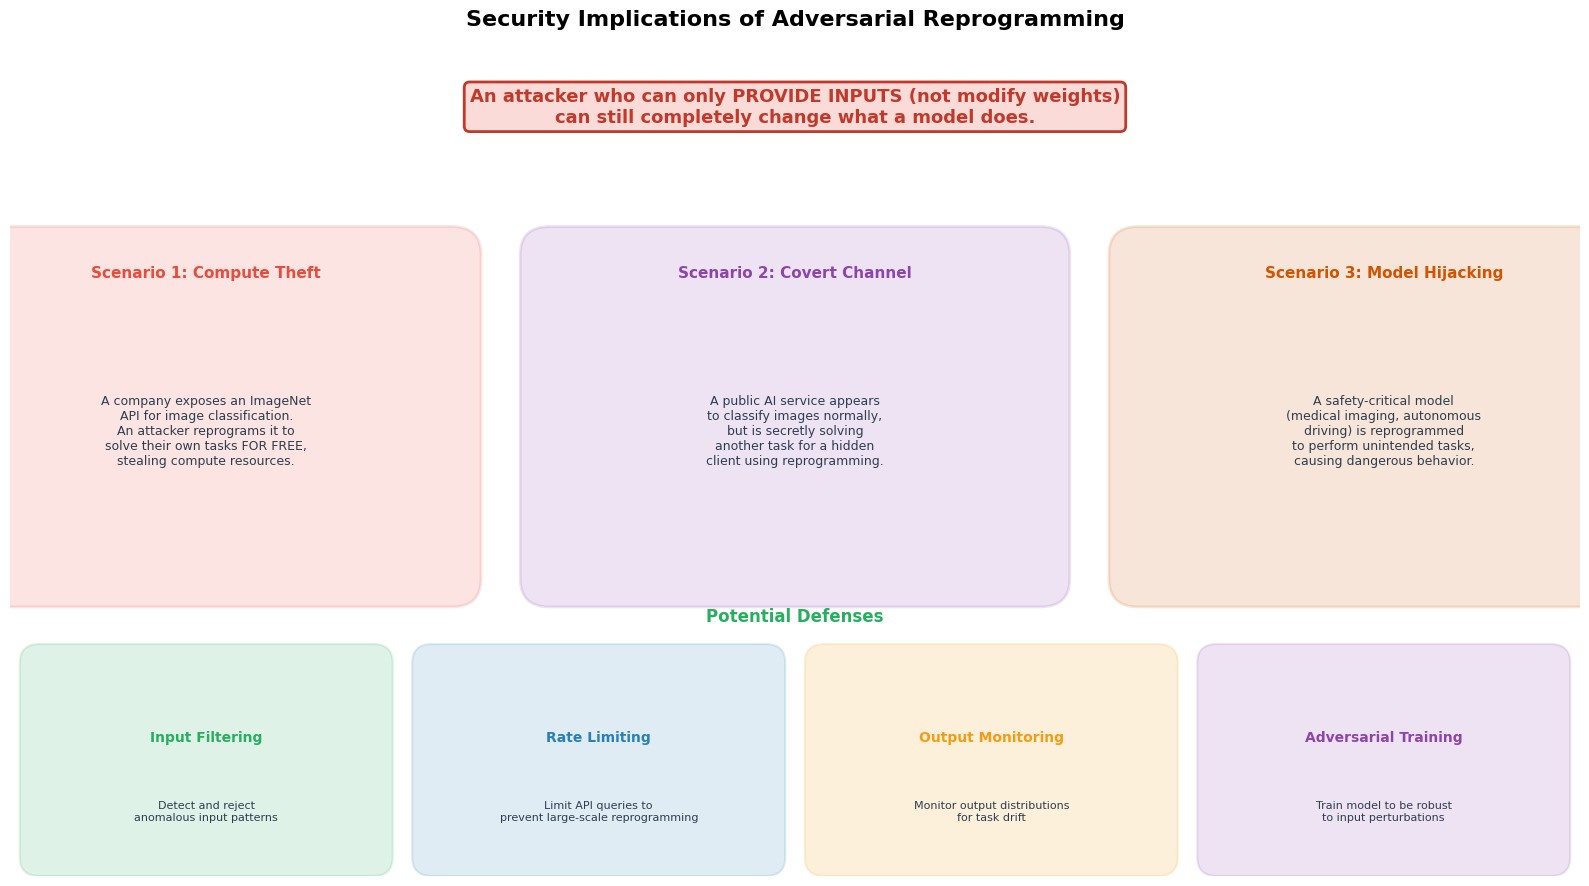

In [13]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')
fig.suptitle('Security Implications of Adversarial Reprogramming', 
             fontsize=16, fontweight='bold')

# ---- Title ----
ax.text(8, 8.5, 'An attacker who can only PROVIDE INPUTS (not modify weights)\ncan still completely change what a model does.',
        ha='center', va='top', fontsize=13, color='#c0392b', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='#c0392b', linewidth=2))

# ---- Three threat scenarios ----
scenarios_sec = [
    {
        'title': 'Scenario 1: Compute Theft',
        'icon': '💻',
        'desc': 'A company exposes an ImageNet\nAPI for image classification.\nAn attacker reprograms it to\nsolve their own tasks FOR FREE,\nstealing compute resources.',
        'color': '#e74c3c',
        'x': 2, 'y': 6
    },
    {
        'title': 'Scenario 2: Covert Channel',
        'icon': '🔐',
        'desc': 'A public AI service appears\nto classify images normally,\nbut is secretly solving\nanother task for a hidden\nclient using reprogramming.',
        'color': '#8e44ad',
        'x': 8, 'y': 6
    },
    {
        'title': 'Scenario 3: Model Hijacking',
        'icon': '🎯',
        'desc': 'A safety-critical model\n(medical imaging, autonomous\ndriving) is reprogrammed\nto perform unintended tasks,\ncausing dangerous behavior.',
        'color': '#d35400',
        'x': 14, 'y': 6
    }
]

for sc in scenarios_sec:
    rect = mpatches.FancyBboxPatch((sc['x'] - 2.5, sc['y'] - 2.8), 5, 3.5,
                                     boxstyle="round,pad=0.3",
                                     facecolor=sc['color'], alpha=0.15,
                                     edgecolor=sc['color'], linewidth=2)
    ax.add_patch(rect)
    ax.text(sc['x'], sc['y'] + 0.5, sc['title'], ha='center', va='center',
            fontsize=11, fontweight='bold', color=sc['color'])
    ax.text(sc['x'], sc['y'] - 1.2, sc['desc'], ha='center', va='center',
            fontsize=9, color='#2c3e50')

# ---- Defenses ----
defenses = [
    ('Input Filtering', 'Detect and reject\nanomalous input patterns', '#27ae60'),
    ('Rate Limiting', 'Limit API queries to\nprevent large-scale reprogramming', '#2980b9'),
    ('Output Monitoring', 'Monitor output distributions\nfor task drift', '#f39c12'),
    ('Adversarial Training', 'Train model to be robust\nto input perturbations', '#8e44ad'),
]

ax.text(8, 2.8, 'Potential Defenses', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#27ae60')

for i, (name, desc, color) in enumerate(defenses):
    x_pos = 2 + i * 4
    rect = mpatches.FancyBboxPatch((x_pos - 1.7, 0.2), 3.4, 2.1,
                                     boxstyle="round,pad=0.2",
                                     facecolor=color, alpha=0.15,
                                     edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x_pos, 1.5, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(x_pos, 0.7, desc, ha='center', va='center',
            fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.savefig('security_implications.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Key Takeaways & Summary

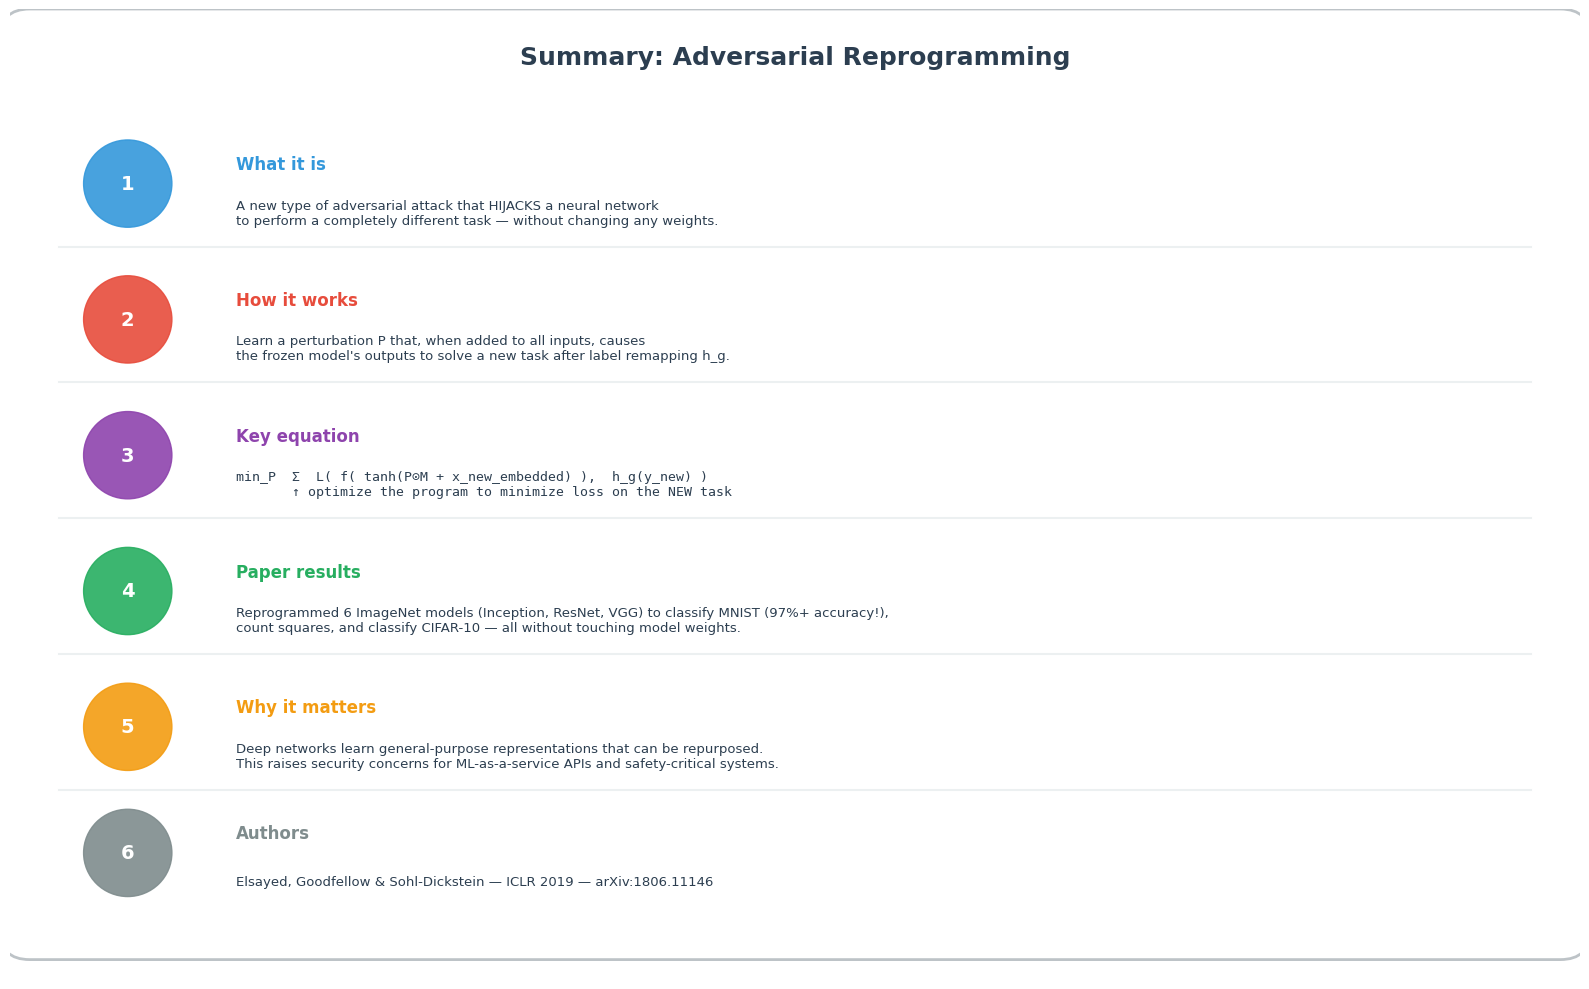

In [14]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(8, 9.5, 'Summary: Adversarial Reprogramming', 
        ha='center', va='center', fontsize=18, fontweight='bold', color='#2c3e50')

takeaways = [
    {
        'num': '1',
        'title': 'What it is',
        'content': 'A new type of adversarial attack that HIJACKS a neural network\nto perform a completely different task — without changing any weights.',
        'color': '#3498db',
        'y': 8.2
    },
    {
        'num': '2',
        'title': 'How it works',
        'content': 'Learn a perturbation P that, when added to all inputs, causes\nthe frozen model\'s outputs to solve a new task after label remapping h_g.',
        'color': '#e74c3c',
        'y': 6.8
    },
    {
        'num': '3',
        'title': 'Key equation',
        'content': 'min_P  Σ  L( f( tanh(P⊙M + x_new_embedded) ),  h_g(y_new) )\n       ↑ optimize the program to minimize loss on the NEW task',
        'color': '#8e44ad',
        'y': 5.4
    },
    {
        'num': '4',
        'title': 'Paper results',
        'content': 'Reprogrammed 6 ImageNet models (Inception, ResNet, VGG) to classify MNIST (97%+ accuracy!),\ncount squares, and classify CIFAR-10 — all without touching model weights.',
        'color': '#27ae60',
        'y': 4.0
    },
    {
        'num': '5',
        'title': 'Why it matters',
        'content': 'Deep networks learn general-purpose representations that can be repurposed.\nThis raises security concerns for ML-as-a-service APIs and safety-critical systems.',
        'color': '#f39c12',
        'y': 2.6
    },
    {
        'num': '6',
        'title': 'Authors',
        'content': 'Elsayed, Goodfellow & Sohl-Dickstein — ICLR 2019 — arXiv:1806.11146',
        'color': '#7f8c8d',
        'y': 1.3
    },
]

for item in takeaways:
    color = item['color']
    y = item['y']
    
    # Number circle
    circle = plt.Circle((1.2, y), 0.45, color=color, alpha=0.9)
    ax.add_patch(circle)
    ax.text(1.2, y, item['num'], ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')
    
    # Title
    ax.text(2.3, y + 0.2, item['title'], ha='left', va='center',
            fontsize=12, fontweight='bold', color=color)
    
    # Content
    ax.text(2.3, y - 0.3, item['content'], ha='left', va='center',
            fontsize=9.5, color='#2c3e50', family='monospace' if item['num'] == '3' else 'sans-serif')
    
    # Separator line
    if item['num'] != '6':
        ax.plot([0.5, 15.5], [y - 0.65, y - 0.65], color='#ecf0f1', linewidth=1.5)

# Border
border = mpatches.FancyBboxPatch((0.2, 0.5), 15.6, 9.2,
                                   boxstyle="round,pad=0.3",
                                   facecolor='none', edgecolor='#bdc3c7', linewidth=2)
ax.add_patch(border)

plt.tight_layout()
plt.savefig('summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Comparison: Classic Adversarial Attacks vs Reprogramming

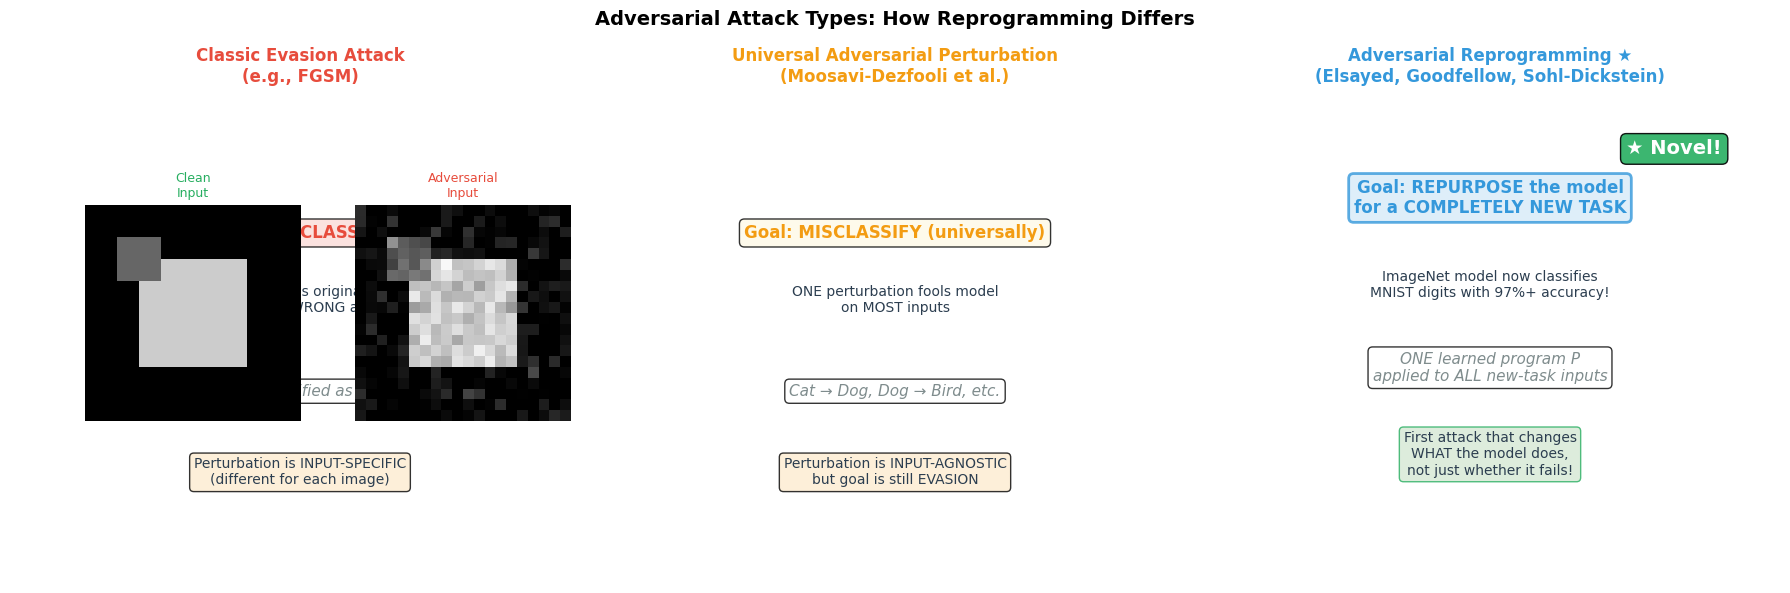

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Adversarial Attack Types: How Reprogramming Differs', 
             fontsize=14, fontweight='bold')

np.random.seed(7)

# ---- Type 1: Classic Evasion Attack ----
ax = axes[0]
ax.set_title('Classic Evasion Attack\n(e.g., FGSM)', fontsize=12, fontweight='bold', color='#e74c3c')

# Create a simple image
img_clean = np.zeros((20, 20))
img_clean[5:15, 5:15] = 0.8  # a square "cat"
img_clean[3:7, 3:7] = 0.4   # ear detail
perturbation = np.random.randn(20, 20) * 0.1
img_adversarial = np.clip(img_clean + perturbation, 0, 1)

# Show both
ax2_1 = fig.add_axes([0.05, 0.25, 0.12, 0.45])
ax2_1.imshow(img_clean, cmap='gray', vmin=0, vmax=1)
ax2_1.set_title('Clean\nInput', fontsize=9, color='#27ae60')
ax2_1.axis('off')

ax2_2 = fig.add_axes([0.2, 0.25, 0.12, 0.45])
ax2_2.imshow(img_adversarial, cmap='gray', vmin=0, vmax=1)
ax2_2.set_title('Adversarial\nInput', fontsize=9, color='#e74c3c')
ax2_2.axis('off')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Comparison text
props = dict(boxstyle='round', facecolor='#fadbd8', alpha=0.8)
ax.text(5, 7, 'Goal: MISCLASSIFY', ha='center', fontsize=12, fontweight='bold', 
        color='#e74c3c', bbox=props)
ax.text(5, 5.5, 'Model still does original task\nbut gets the WRONG answer', 
        ha='center', fontsize=10, color='#2c3e50')
ax.text(5, 3.8, 'Cat → classified as Dog', ha='center', fontsize=11, 
        style='italic', color='#7f8c8d',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(5, 2.0, 'Perturbation is INPUT-SPECIFIC\n(different for each image)', 
        ha='center', fontsize=10, color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.8))

# ---- Type 2: Universal Perturbation ----
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Universal Adversarial Perturbation\n(Moosavi-Dezfooli et al.)', 
             fontsize=12, fontweight='bold', color='#f39c12')

props2 = dict(boxstyle='round', facecolor='#fef9e7', alpha=0.8)
ax.text(5, 7, 'Goal: MISCLASSIFY (universally)', ha='center', fontsize=12, 
        fontweight='bold', color='#f39c12', bbox=props2)
ax.text(5, 5.5, 'ONE perturbation fools model\non MOST inputs', 
        ha='center', fontsize=10, color='#2c3e50')
ax.text(5, 3.8, 'Cat → Dog, Dog → Bird, etc.', ha='center', fontsize=11, 
        style='italic', color='#7f8c8d',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(5, 2.0, 'Perturbation is INPUT-AGNOSTIC\nbut goal is still EVASION', 
        ha='center', fontsize=10, color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.8))

# ---- Type 3: Adversarial Reprogramming ----
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Adversarial Reprogramming ★\n(Elsayed, Goodfellow, Sohl-Dickstein)',
             fontsize=12, fontweight='bold', color='#3498db')

props3 = dict(boxstyle='round', facecolor='#d6eaf8', alpha=0.8, edgecolor='#3498db', linewidth=2)
ax.text(5, 7.5, 'Goal: REPURPOSE the model\nfor a COMPLETELY NEW TASK', ha='center', 
        fontsize=12, fontweight='bold', color='#3498db', bbox=props3)
ax.text(5, 5.8, 'ImageNet model now classifies\nMNIST digits with 97%+ accuracy!', 
        ha='center', fontsize=10, color='#2c3e50')
ax.text(5, 4.1, 'ONE learned program P\napplied to ALL new-task inputs', ha='center', 
        fontsize=11, style='italic', color='#7f8c8d',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(5, 2.2, 'First attack that changes\nWHAT the model does,\nnot just whether it fails!', 
        ha='center', fontsize=10, color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#d5e8d4', alpha=0.8, edgecolor='#27ae60'))

# Star badge
ax.text(9, 9, '★ Novel!', fontsize=14, ha='right', va='top', 
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#27ae60', alpha=0.9))

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion

### What We Learned

1. **Adversarial reprogramming** hijacks a model's computation for a new task
2. The attack works by optimizing a **learned perturbation P** that reprograms inputs
3. The key components are:
   - **h_f**: Input mapping (embed new input + add adversarial program)
   - **h_g**: Output mapping (remap model labels to new task labels)
4. The paper achieved **97%+ accuracy** on MNIST using frozen ImageNet classifiers
5. This reveals that **deep networks contain surprisingly general-purpose representations**

### Further Reading
- **Paper**: [arXiv:1806.11146](https://arxiv.org/abs/1806.11146) — Elsayed, Goodfellow, Sohl-Dickstein
- **Related**: Universal Adversarial Perturbations (Moosavi-Dezfooli et al., 2017)
- **Related**: Backdoor/Trojan attacks on neural networks
- **Defense**: Adversarial training, certified defenses, input preprocessing

---
*Notebook created for educational purposes. All examples use simplified toy models to illustrate core concepts from the paper.*